In [1]:
# Husayn El Sharif
# use conda environment energy_demand_ml_env001

## PUDL Hourly operations data for SOCO region

Pull PUDL hourly operations data for the SOCO region which includes Georgia, Alabama, and parts of Mississippi.

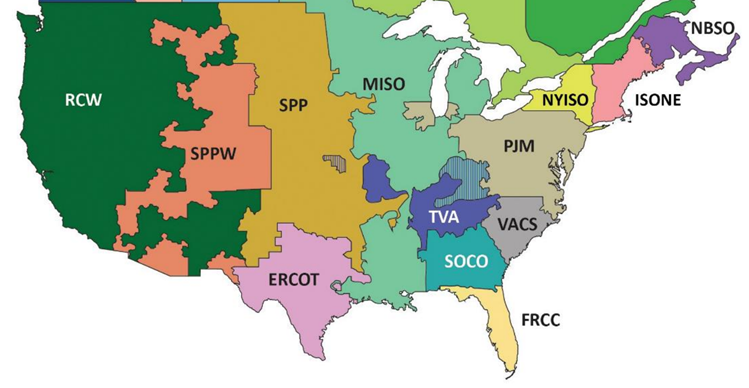

Data Source: https://data.catalyst.coop/preview/pudl/out_eia930__hourly_operations?return_q=out_eia930__hourly_operations

## Data Dictionary

| Column | Description |
|--------|-------------|
| datetime_utc | Date and time converted to Coordinated Universal Time (UTC). |
| balancing_authority_code_eia | EIA short code identifying a balancing authority. May include Canadian and Mexican BAs. |
| net_generation_reported_mwh | Unaltered originally reported net generation for the specified period. |
| net_generation_adjusted_mwh | Reported net generation adjusted by EIA to reflect non-physical commercial transfers through pseudo-ties and dynamic scheduling. |
| net_generation_imputed_eia_mwh | Reported net generation with outlying values removed and missing values imputed by EIA. |
| interchange_reported_mwh | Original reported energy interchange between adjacent balancing authorities. |
| interchange_adjusted_mwh | Energy interchange between adjacent balancing authorities, adjusted by EIA to reflect non-physical commercial transfers through pseudo-ties and dynamic scheduling. |
| interchange_imputed_eia_mwh | Energy interchange between adjacent balancing authorities, with outliers and missing values imputed by EIA. |
| demand_reported_mwh | Originally reported electricity demand, calculated by taking the net generation within the BA and subtracting the interchange with adjacent BAs. |
| demand_adjusted_mwh | Electricity demand adjusted by EIA to reflect non-physical commercial transfers through pseudo-ties and dynamic scheduling. |
| demand_imputed_pudl_mwh | Electricity demand calculated by subtracting BA interchange from net generation, with outliers and missing values imputed in PUDL. |
| demand_imputed_pudl_mwh_imputation_code | Code describing why a demand value was flagged for imputation. |
| demand_imputed_eia_mwh | Electricity demand calculated by subtracting BA interchange from net generation, with outliers and missing values imputed by EIA. |
| demand_forecast_mwh | Day ahead demand forecast. |



In [2]:
# Import necessary libraries
from pathlib import Path
import requests
import pandas as pd

In [3]:
# PUDL hourly operations parquet
# Stable namespace is documented by PUDL for versioned/latest stable access.
# Some PUDL releases use "out_eia930__hourly_operations.parquet"
# and some published links may use "core_eia930__hourly_subregion_operations.parquet".
CANDIDATE_URLS = [
    "https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/stable/out_eia930__hourly_operations.parquet",
    "https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/stable/out_eia930__hourly_operations.parquet",
    "https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/nightly/out_eia930__hourly_operations.parquet",
    "https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/nightly/out_eia930__hourly_operations.parquet",
]

output_dir = Path("data")
output_dir.mkdir(exist_ok=True)

parquet_path = output_dir / "eia930_hourly_operations.parquet"
soco_csv_path = output_dir / "soco_hourly_operations.csv"



In [4]:
# Try downloading the parquet file from each candidate URL until one works, then save it to the specified destination.
def download_first_working_file(urls, destination):
    for url in urls:
        try:
            print(f"Trying: {url}")
            with requests.get(url, stream=True, timeout=60) as r:
                if r.status_code == 200:
                    r.raise_for_status()
                    with open(destination, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024 * 1024):
                            if chunk:
                                f.write(chunk)
                    print(f"Downloaded successfully from:\n{url}")
                    return url
                else:
                    print(f"  Skipped, status {r.status_code}")
        except Exception as e:
            print(f"  Failed: {e}")

    raise RuntimeError("Could not download the PUDL hourly operations parquet from any candidate URL.")

downloaded_url = download_first_working_file(CANDIDATE_URLS, parquet_path)



Trying: https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/stable/out_eia930__hourly_operations.parquet
Downloaded successfully from:
https://s3.us-west-2.amazonaws.com/pudl.catalyst.coop/stable/out_eia930__hourly_operations.parquet


In [5]:
# Read parquet
df = pd.read_parquet(parquet_path)

print("\nColumns:")
print(df.columns.tolist())

# Filter to SOCO
# Main expected field is balancing_authority_code_eia
if "balancing_authority_code_eia" not in df.columns:
    raise KeyError("Expected column 'balancing_authority_code_eia' not found.")

soco = df.loc[df["balancing_authority_code_eia"] == "SOCO"].copy()

# Parse datetime if present
if "datetime_utc" in soco.columns:
    soco["datetime_utc"] = pd.to_datetime(soco["datetime_utc"], utc=True)

# Sort if possible
sort_cols = [c for c in ["datetime_utc", "balancing_authority_subregion_code_eia"] if c in soco.columns]
if sort_cols:
    soco = soco.sort_values(sort_cols).reset_index(drop=True)

# Save extracted SOCO rows
soco.to_csv(soco_csv_path, index=False)


Columns:
['datetime_utc', 'balancing_authority_code_eia', 'net_generation_reported_mwh', 'net_generation_adjusted_mwh', 'net_generation_imputed_eia_mwh', 'interchange_reported_mwh', 'interchange_adjusted_mwh', 'interchange_imputed_eia_mwh', 'demand_reported_mwh', 'demand_adjusted_mwh', 'demand_imputed_pudl_mwh', 'demand_imputed_pudl_mwh_imputation_code', 'demand_imputed_eia_mwh', 'demand_forecast_mwh']


In [6]:
print(f"\nDownloaded file: {parquet_path}")
print(f"Extracted SOCO rows: {len(soco):,}")
print(f"Saved SOCO CSV: {soco_csv_path}")




Downloaded file: data\eia930_hourly_operations.parquet
Extracted SOCO rows: 92,833
Saved SOCO CSV: data\soco_hourly_operations.csv


In [7]:
soco

,datetime_utc,balancing_authority_code_eia,net_generation_reported_mwh,net_generation_adjusted_mwh,net_generation_imputed_eia_mwh,interchange_reported_mwh,interchange_adjusted_mwh,interchange_imputed_eia_mwh,demand_reported_mwh,demand_adjusted_mwh,demand_imputed_pudl_mwh,demand_imputed_pudl_mwh_imputation_code,demand_imputed_eia_mwh,demand_forecast_mwh
0,2015-07-01 06:00:00+00:00,SOCO,25242.0,25242.0,NaN,419.0,419.0,NaN,24823.0,24823.0,24823.000000,NaN,NaN,24149.0
1,2015-07-01 07:00:00+00:00,SOCO,24580.0,24580.0,NaN,459.0,459.0,NaN,24121.0,24121.0,24121.000000,NaN,NaN,23026.0
2,2015-07-01 08:00:00+00:00,SOCO,23943.0,23943.0,NaN,560.0,560.0,NaN,23383.0,23383.0,23383.000000,NaN,NaN,22280.0
3,2015-07-01 09:00:00+00:00,SOCO,23692.0,23692.0,NaN,508.0,508.0,NaN,23184.0,23184.0,23184.000000,NaN,NaN,22044.0
4,2015-07-01 10:00:00+00:00,SOCO,24190.0,24190.0,NaN,510.0,510.0,NaN,23680.0,23680.0,23680.000000,NaN,NaN,22474.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92828,2026-02-01 02:00:00+00:00,SOCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26530.679688,missing_value,NaN,42908.0
92829,2026-02-01 03:00:00+00:00,SOCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26132.539062,missing_value,NaN,42362.0
92830,2026-02-01 04:00:00+00:00,SOCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25221.031250,missing_value,NaN,41567.0
92831,2026-02-01 05:00:00+00:00,SOCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24196.906250,missing_value,NaN,40971.0
